# FFT of a kinetic-energy time series

Interactive companion to [`fft_KineticEnergy.py`](fft_KineticEnergy.py).

It reads a per-run `KineticEnergy_timeSeries.npz` (produced by
`batch_KineticEnergy.py`, containing `t`, `Ek_frame` and the PIV sampling
frequency `fps`), computes the **FFT** of `Ek(t)`, and draws two panels:

1. the kinetic-energy time series `Ek(t)`;
2. its amplitude spectrum `|FFT|` versus frequency.

The one-sided amplitude is normalised as `|FFT| * 2 / N` so a pure tone reads
as its physical amplitude (DC and Nyquist bins keep the `1/N` scaling). By
default the mean is removed first so the DC term does not dwarf the rest. If the
libration frequency can be parsed from the run name, dashed guides are drawn at
`flib` and `2*flib`.

Run with an environment that has **numpy / matplotlib** (e.g. `dpivsoft`).

## 1. Imports

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

NPZ_NAME = "KineticEnergy_timeSeries.npz"
FLIB_DIVISOR = 1000.0   # folder token 'flib0400' -> 0.400 Hz (matches batch)

## 2. Configuration

Edit these, then run the cells below. `PATH` may be the `.npz` file itself or a
run folder (its `PostProcessing/KineticEnergy_timeSeries.npz` is used).

In [2]:
# --- edit me -------------------------------------------------------------
PATH    = "/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_bottomOnly/frot0.50Hz_flib0.500Hz_dphi24deg/PostProcessing"   # run folder or .npz
DETREND = True        # remove the mean before the estimate (kills the DC spike)
LOGY    = True        # logarithmic power axis (False -> linear)
SAVE    = True       # also write a PNG next to the .npz
OUTPUT  = None        # PNG path; None -> KineticEnergy_Periodogram.png beside the .npz
# -------------------------------------------------------------------------

## 3. Helper functions

Same logic as the script.

In [3]:
def resolve_npz(path):
    """Accept the .npz path directly or a run folder containing it."""
    if os.path.isdir(path):
        cand = os.path.join(path, "PostProcessing", NPZ_NAME)
        if os.path.isfile(cand):
            return cand
        cand = os.path.join(path, NPZ_NAME)
        if os.path.isfile(cand):
            return cand
        raise FileNotFoundError("No %s under %s" % (NPZ_NAME, path))
    if os.path.isfile(path):
        return path
    raise FileNotFoundError(path)


def parse_flib(run_name):
    """Libration frequency (Hz) from a run name, or None.

    Accepts the current 'flib0.400Hz' and the legacy 'flib0400' (also 0.4 Hz). The
    Hz form must be tried first: the legacy pattern would read 'flib0.400Hz' as
    'flib0' -> 0.0.
    """
    name = str(run_name)
    m = re.search(r"flib([\d.]+)Hz", name)
    if m:
        return float(m.group(1))
    m = re.search(r"flib(\d+)", name)
    return float(m.group(1)) / FLIB_DIVISOR if m else None


def compute_fft(ek, fps, detrend=True):
    """Return (freq, amp, fft) for the positive-frequency half of Ek(t).

    `fft` is the complex one-sided spectrum from numpy.fft.rfft and `amp` is
    its normalised amplitude (|FFT| * 2 / N, so a pure tone reads as its
    physical amplitude; the DC bin keeps the 1/N scaling).
    """
    ek = np.asarray(ek, dtype=float)
    # Fill any NaNs (e.g. fully-masked frames) with the series mean.
    if np.any(np.isnan(ek)):
        ek = np.where(np.isnan(ek), np.nanmean(ek), ek)
    if detrend:
        ek = ek - ek.mean()
    n = ek.size
    fft = np.fft.rfft(ek)
    freq = np.fft.rfftfreq(n, d=1.0 / fps)
    amp = np.abs(fft) * 2.0 / n
    amp[0] = np.abs(fft[0]) / n            # DC term is not doubled
    if n % 2 == 0:
        amp[-1] = np.abs(fft[-1]) / n      # Nyquist term is not doubled either
    return freq, amp, fft

## 4. Load the time series

In [4]:
npz_path = resolve_npz(PATH)
print("Reading %s" % npz_path)

data = np.load(npz_path, allow_pickle=True)
t = data["t"]
ek = data["Ek_frame"]
fps = float(data["fps"]) if "fps" in data.files else 1.0
run = str(data["run"]) if "run" in data.files else os.path.basename(
    os.path.dirname(npz_path))

flib = parse_flib(run)
print("run  = %s" % run)
print("fps  = %g Hz   nframes = %d" % (fps, ek.size))
print("flib = %s" % ("%g Hz" % flib if flib else "unknown"))

Reading /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_bottomOnly/frot050_flib0500_dphi24deg/PostProcessing/KineticEnergy_timeSeries.npz
run  = frot050_flib0500_dphi24deg
fps  = 30 Hz   nframes = 500
flib = 0.5 Hz


## 5. Compute the FFT

In [5]:
freq, amp, fft = compute_fft(ek, fps, detrend=DETREND)

# Peak frequency (ignoring the DC bin).
if amp.size > 1:
    k = 1 + int(np.argmax(amp[1:]))
    print("peak at %.4f Hz  (amplitude = %.3e)" % (freq[k], amp[k]))
    if flib:
        print("  flib = %.4f Hz, 2*flib = %.4f Hz" % (flib, 2 * flib))

peak at 1.0200 Hz  (amplitude = 1.894e-05)
  flib = 0.5000 Hz, 2*flib = 1.0000 Hz


## 6. Plot

Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_bottomOnly/frot050_flib0500_dphi24deg/PostProcessing/KineticEnergy_FFT.png


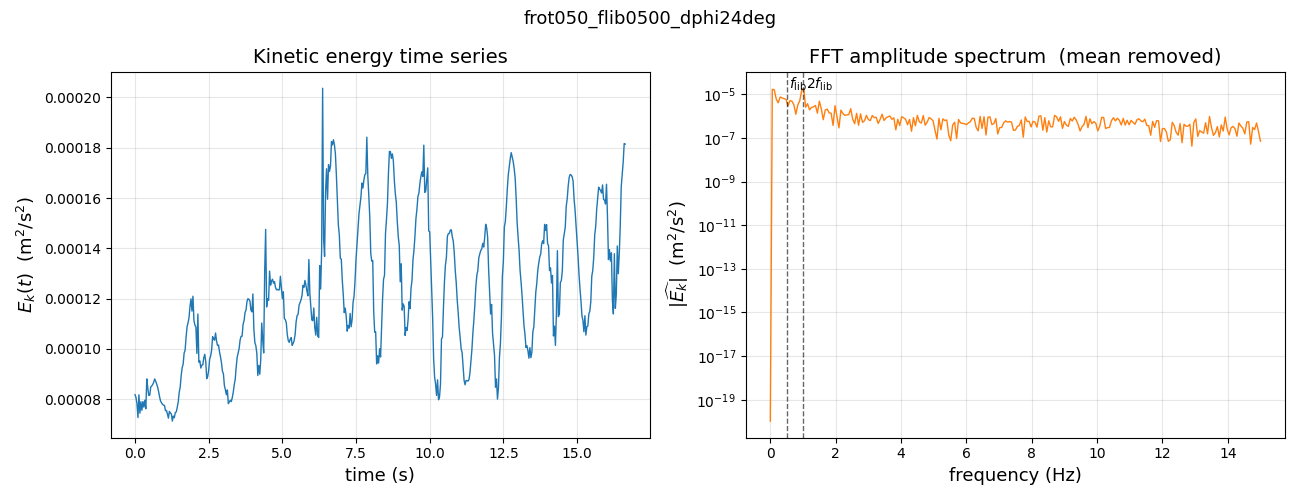

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: time series
axes[0].plot(t, ek, color="C0", lw=1)
axes[0].set_xlabel("time (s)", fontsize=13)
axes[0].set_ylabel(r"$E_k(t)$  (m$^2$/s$^2$)", fontsize=13)
axes[0].set_title("Kinetic energy time series", fontsize=14)
axes[0].grid(True, alpha=0.3)

# Panel 2: amplitude spectrum
if LOGY:
    axes[1].semilogy(freq, amp, color="C1", lw=1)
else:
    axes[1].plot(freq, amp, color="C1", lw=1)
axes[1].set_xlabel("frequency (Hz)", fontsize=13)
axes[1].set_ylabel(r"$|\widehat{E_k}|$  (m$^2$/s$^2$)", fontsize=13)
ttl = "FFT amplitude spectrum" + ("  (mean removed)" if DETREND else "")
axes[1].set_title(ttl, fontsize=14)
axes[1].grid(True, alpha=0.3, which="both")
if flib:
    for f, lbl in ((flib, r"$f_{\mathrm{lib}}$"),
                   (2 * flib, r"$2f_{\mathrm{lib}}$")):
        if f <= freq.max():
            axes[1].axvline(f, color="k", ls="--", lw=1, alpha=0.6)
            axes[1].annotate(lbl, xy=(f, 1), xycoords=("data", "axes fraction"),
                             xytext=(2, -12), textcoords="offset points",
                             fontsize=10)

fig.suptitle(run, fontsize=13)
fig.tight_layout()

if SAVE:
    output = OUTPUT or os.path.join(
        os.path.dirname(npz_path), "KineticEnergy_FFT.png")
    fig.savefig(output, dpi=200, bbox_inches="tight")
    print("Figure written to:\n  %s" % output)

plt.show()